![imagen](Airbnb.png)

# Exercise 4

To begin characterizing the various types of accommodations available on Airbnb in Amsterdam, the following hypotheses are of interest:

1.    If a property with a review score between 80 and 89 points is listed, 80% of the listings are likely to be private rooms, houses, or apartments.
  
2.    If a house or apartment is rented, 30% of the listings will have a review score between 80 and 100 points.

3.    30% of the listings are private rooms with review scores between 90 and 100 points.
  
4.    This hypothesis can be validated using chi-square tests.

# 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

# 2. Load data

In [2]:
data= pd.read_csv('listings_m-2-.csv', sep=',')
data.head()

,id,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2818,https://www.airbnb.com/rooms/2818,2.021040e+13,12/04/2021,Quiet Garden View Room & Super Fast WiFi,Quiet Garden View Room & Super Fast WiFi<br />...,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,...,10.0,9.0,10.0,NaN,t,1,0,1,0,1.90
1,20168,https://www.airbnb.com/rooms/20168,2.021040e+13,12/04/2021,Studio with private bathroom in the centre 1,17th century Dutch townhouse in the heart of t...,Located just in between famous central canals....,https://a0.muscache.com/pictures/69979628/fd6a...,59484,https://www.airbnb.com/users/show/59484,...,10.0,10.0,9.0,0363 CBB3 2C10 0C2A 1E29,t,2,0,2,0,2.50
2,25428,https://www.airbnb.com/rooms/25428,2.021040e+13,11/04/2021,"Lovely, 1 bed apt in Ctr (w.lift) -3/20-6/20(f...",Lovely apt in Centre ( lift & fireplace) near ...,NaN,https://a0.muscache.com/pictures/138431/7079a9...,56142,https://www.airbnb.com/users/show/56142,...,10.0,10.0,10.0,NaN,f,2,2,0,0,0.13
3,27886,https://www.airbnb.com/rooms/27886,2.021040e+13,11/04/2021,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,...,10.0,10.0,10.0,0363 974D 4986 7411 88D8,t,1,0,1,0,1.94
4,28871,https://www.airbnb.com/rooms/28871,2.021040e+13,13/04/2021,Comfortable double room,<b>The space</b><br />In a monumental house ri...,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,...,10.0,10.0,10.0,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,2.59


# 3. Hypothesis

#### 1. If a property with a review score between 80 and 89 points is listed, 80% of the listings are likely to be private rooms, houses, or apartments.

In [3]:
review_scores = data[['review_scores_rating', 'room_type']]
#We filter the values between 80 and 89 for 'review_scores_rating'
review_scores = review_scores[
    (review_scores['review_scores_rating'] >= 80) &
    (review_scores['review_scores_rating'] <= 89)
]
review_scores.head()

,review_scores_rating,room_type
1,89.0,Private room
8,80.0,Entire home/apt
33,89.0,Entire home/apt
36,85.0,Entire home/apt
42,80.0,Entire home/apt


In [4]:
#Frequency table showing the proportion of each ‘room_type’ in the resulting dataset
freq_table = review_scores['room_type'].value_counts().reset_index()
freq_table.columns = ['room_type', 'count']

freq_table['frequency'] = freq_table['count'] / freq_table['count'].sum() *100
freq_table['absolute_frequency'] = freq_table['count'].cumsum()
freq_table['cumulative_relative_frequency'] = freq_table['frequency'].cumsum()

freq_table

,room_type,count,frequency,absolute_frequency,cumulative_relative_frequency
0,Entire home/apt,1031,71.152519,1031,71.152519
1,Private room,394,27.191166,1425,98.343685
2,Hotel room,17,1.173223,1442,99.516908
3,Shared room,7,0.483092,1449,100.000000


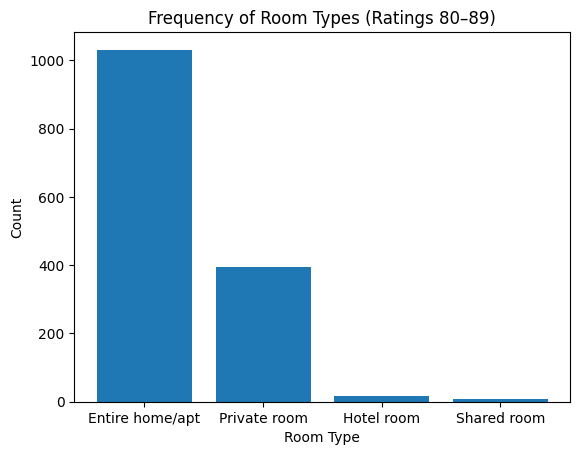

In [5]:
plt.figure()

plt.bar(freq_table['room_type'], freq_table['count'])

plt.title('Frequency of Room Types (Ratings 80–89)')
plt.xlabel('Room Type')
plt.ylabel('Count')

plt.show()

#### The hypothesis is accepted, since when filtering scores between 80 and 89, approximately 98% of the listings correspond to private rooms, houses, or apartments, exceeding the proposed 80% threshold.

#### 2. If a house or apartment is rented, 30% of the listings will have a review score between 80 and 100 points.

In [6]:
home_apt = data[data['room_type'] == 'Entire home/apt'][['review_scores_rating', 'room_type']]

home_apt_80_100 = home_apt[
    (home_apt['review_scores_rating'] >= 80) &
    (home_apt['review_scores_rating'] <= 100)
]

In [7]:
percentage = len(home_apt_80_100) / len(home_apt) * 100
print(percentage)

84.2040875071963


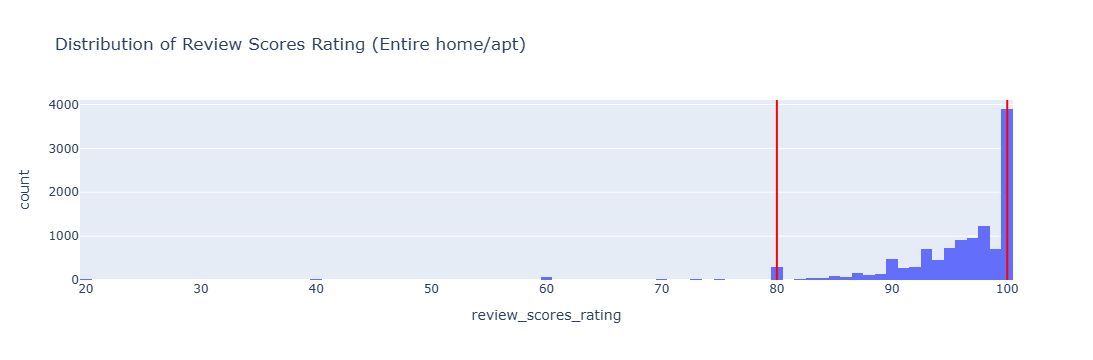

In [8]:
fig = px.histogram(
    home_apt,
    x='review_scores_rating',
    nbins=100,
    title='Distribution of Review Scores Rating (Entire home/apt)'
)

fig.add_vline(x=80, line_color='red')
fig.add_vline(x=100, line_color='red')

fig.show()

#### The hypothesis is accepted, since the percentage of “Entire home/apt” listings with a rating between 80 and 100 points is 84.2%, which is significantly higher than the proposed 30%.

#### 3. 30% of the listings are private rooms with review scores between 90 and 100 points.

In [9]:
private_rooms = data[data['room_type'] == 'Private room'][['review_scores_rating', 'room_type']]

private_rooms = private_rooms[
    (private_rooms['review_scores_rating'] >= 90) &
    (private_rooms['review_scores_rating'] <= 100)
]

In [10]:
percentage_private_rooms = len(private_rooms) / len(data) * 100
print(percentage_private_rooms)

14.788218793828891


#### The hypothesis is rejected, since the percentage of publications corresponding to private rooms with a review score between 90 and 100 is 14.79%, which is lower than the proposed 30%.